In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix

In [ ]:
df = pd.read_excel("/content/factory_sensor_dataset.xlsx")

In [ ]:
df

,RPM,Vibration,Pressure,Machine_Mode,Temperature,Defective
0,1660,2.42,63.90,Eco,83.94,1
1,2094,1.48,27.66,High-Speed,71.82,1
2,1930,2.23,35.00,High-Speed,78.75,1
3,1895,0.63,54.83,High-Speed,74.65,1
4,2438,0.84,72.03,Eco,84.54,1
...,...,...,...,...,...,...
195,1423,2.43,40.49,Eco,72.02,1
196,1816,1.46,52.24,Standard,74.88,1
197,1680,1.17,47.61,Standard,69.38,0
198,2849,1.51,55.09,Standard,93.16,1


In [ ]:
X = df[['RPM']]
y = df['Temperature']

model = LinearRegression()

model.fit(X,y)

prediction = model.predict(X)

mse = mean_squared_error(y,prediction)

print("MSE:",mse)

MSE: 64.90177721050605


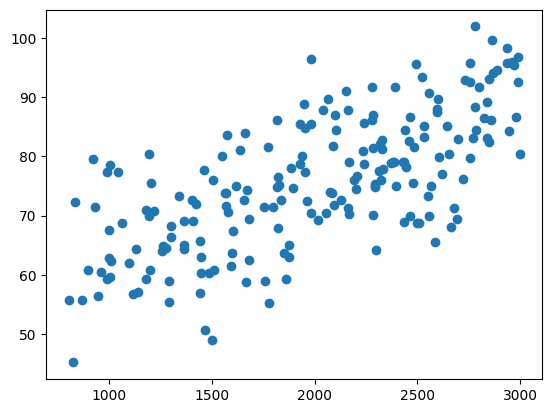

In [ ]:
plt.scatter(df['RPM'],df['Temperature'])

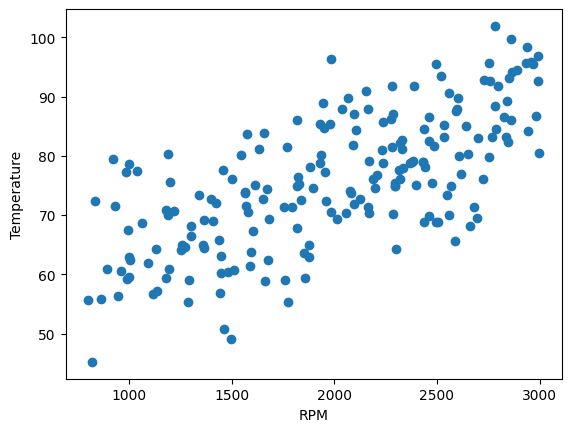

In [ ]:
plt.scatter(df['RPM'],df['Temperature'])
plt.xlabel("RPM")
plt.ylabel("Temperature")
plt.show()

In [ ]:
X = df[['RPM','Vibration','Pressure']]

In [ ]:
y = df['Temperature']

In [ ]:
model2 = LinearRegression()


In [ ]:

model2.fit(X,y)


LinearRegression()

In [ ]:
prediction2 = model2.predict(X)


In [ ]:

mse2 = mean_squared_error(y,prediction2)

In [ ]:
mse2

9.614046380136962

In [ ]:
import joblib

joblib.dump(model2,'factory_model.pkl')

['factory_model.pkl']

In [ ]:
df = pd.get_dummies(df,columns=['Machine_Mode'],drop_first=True)

In [ ]:
df

,RPM,Vibration,Pressure,Temperature,Defective,Machine_Mode_High-Speed,Machine_Mode_Standard
0,1660,2.42,63.90,83.94,1,False,False
1,2094,1.48,27.66,71.82,1,True,False
2,1930,2.23,35.00,78.75,1,True,False
3,1895,0.63,54.83,74.65,1,True,False
4,2438,0.84,72.03,84.54,1,False,False
...,...,...,...,...,...,...,...
195,1423,2.43,40.49,72.02,1,False,False
196,1816,1.46,52.24,74.88,1,False,True
197,1680,1.17,47.61,69.38,0,False,True
198,2849,1.51,55.09,93.16,1,False,True


In [ ]:
X = df.drop(['Temperature','Defective'],axis='columns')

In [ ]:
X

,RPM,Vibration,Pressure,Machine_Mode_High-Speed,Machine_Mode_Standard
0,1660,2.42,63.90,False,False
1,2094,1.48,27.66,True,False
2,1930,2.23,35.00,True,False
3,1895,0.63,54.83,True,False
4,2438,0.84,72.03,False,False
...,...,...,...,...,...
195,1423,2.43,40.49,False,False
196,1816,1.46,52.24,False,True
197,1680,1.17,47.61,False,True
198,2849,1.51,55.09,False,True


In [ ]:
y = df['Defective']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [ ]:
log_model = LogisticRegression()

In [ ]:
log_model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
accuracy = log_model.score(X_test,y_test)
accuracy

0.75

In [ ]:
p=log_model.predict(X_test)

In [ ]:
p

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0])

In [ ]:
cm=confusion_matrix(y_test,p)
cm

array([[ 9,  5],
       [ 5, 21]])